# Projet IA

## Chargement Individuel des Datasets

### Importation des bibliothèques

In [522]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier


In [523]:
def build_time_features(df_in, df_out):
    in_datetimes = df_in.apply(pd.to_datetime, errors="coerce")
    out_datetimes = df_out.apply(pd.to_datetime, errors="coerce")

    in_minutes = in_datetimes.apply(
        lambda column: column.dt.hour * 60 + column.dt.minute + column.dt.second / 60
    )
    out_minutes = out_datetimes.apply(
        lambda column: column.dt.hour * 60 + column.dt.minute + column.dt.second / 60
    )
    work_duration_hours = (out_minutes - in_minutes) / 60

    return pd.DataFrame(
        {
            "InTimeAvgMinutes": in_minutes.mean(axis=1),
            "InTimeStdMinutes": in_minutes.std(axis=1),
            "InTimeMissingDays": in_minutes.isna().sum(axis=1),
            "OutTimeAvgMinutes": out_minutes.mean(axis=1),
            "OutTimeStdMinutes": out_minutes.std(axis=1),
            "OutTimeMissingDays": out_minutes.isna().sum(axis=1),
            "AvgWorkDurationHours": work_duration_hours.mean(axis=1),
            "StdWorkDurationHours": work_duration_hours.std(axis=1),
            "MissingWorkDurationDays": work_duration_hours.isna().sum(axis=1),
        }
    )

df_employee = pd.read_csv(
    "./Data/employee_survey_data.csv",
    sep=",",
    header=0,
    names=["EmployeeID","EnvironmentSatisfaction","JobSatisfaction","WorkLifeBalance"]
)
df_general = pd.read_csv(
    "./Data/general_data.csv",
    sep=",",
    header=0,
    names=["Age","Attrition","BusinessTravel","Department","DistanceFromHome","Education","EducationField","EmployeeCount","EmployeeID","Gender","JobLevel","JobRole","MaritalStatus","MonthlyIncome","NumCompaniesWorked","Over18","PercentSalaryHike","StandardHours","StockOptionLevel","TotalWorkingYears","TrainingTimesLastYear","YearsAtCompany","YearsSinceLastPromotion","YearsWithCurrManager"]
)
df_manager = pd.read_csv(
    "./Data/manager_survey_data.csv",
    sep=",",
    header=0,
    names=["EmployeeID","JobInvolvement","PerformanceRating"]
)
df_in = pd.read_csv("./Data/in_out_time/in_time.csv", sep=",", header=0, index_col=0)
df_out = pd.read_csv("./Data/in_out_time/out_time.csv", sep=",", header=0, index_col=0)
df_in.index.name = "EmployeeID"
df_out.index.name = "EmployeeID"
df_time_features = build_time_features(df_in, df_out)

# Imputer les valeurs manquantes pour chaque dataset
for df in [df_employee, df_general, df_manager, df_time_features]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) > 0:
        df[cat_cols] = df[cat_cols].fillna("Unknown")

/tmp/ipykernel_11495/3271685107.py:56: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


## Fusion des datasets en un dataframe unique

In [524]:
# Fusionner les quatre sources en utilisant EmployeeID comme clé
# Tous les datasets partagent la même population d'employés, donc une fusion interne ne garde que les employés correspondants.
df_merged = (
    df_general
    .merge(df_employee, on='EmployeeID', how='inner')
    .merge(df_manager, on='EmployeeID', how='inner')
    .merge(df_time_features.reset_index(), on='EmployeeID', how='inner')
)
print('Taille du dataframe fusionné :', df_merged.shape)
print('Nombre d\'EmployeeID uniques :', df_merged['EmployeeID'].nunique())
print('Lignes avec EmployeeID en double :', df_merged.duplicated(subset=['EmployeeID']).sum())
print('\nColonnes du dataframe fusionné :')
print(df_merged.columns.tolist())

# Utiliser le dataframe fusionné pour le prétraitement et l'analyse ultérieurs
# Cela garde le dataset unifié et préserve les données d'enquête des employés, des managers et du temps.
df_general = df_merged.copy()

Taille du dataframe fusionné : (4410, 38)
Nombre d'EmployeeID uniques : 4410
Lignes avec EmployeeID en double : 0

Colonnes du dataframe fusionné :
['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'InTimeAvgMinutes', 'InTimeStdMinutes', 'InTimeMissingDays', 'OutTimeAvgMinutes', 'OutTimeStdMinutes', 'OutTimeMissingDays', 'AvgWorkDurationHours', 'StdWorkDurationHours', 'MissingWorkDurationDays']


### Informations sur le dataset fusionné

In [525]:
print("-------------------- Dataset Fusionné --------------------")
print("-------------------- HEAD --------------------")
print(df_general.head())
print("-------------------- DESCRIBE --------------------")
print(df_general.describe())
print("-------------------- INFO --------------------")
print(df_general.info())
print("-------------------- Valeurs Manquantes --------------------")
print(df_general.isnull().sum())
print("-------------------- Valeurs en Double --------------------")
print(df_general.duplicated().sum())
print("---------------------------------------------------")

-------------------- Dataset Fusionné --------------------
-------------------- HEAD --------------------
   Age Attrition     BusinessTravel              Department  DistanceFromHome  \
0   51        No      Travel_Rarely                   Sales                 6   
1   31       Yes  Travel_Frequently  Research & Development                10   
2   32        No  Travel_Frequently  Research & Development                17   
3   38        No         Non-Travel  Research & Development                 2   
4   32        No      Travel_Rarely  Research & Development                10   

   Education EducationField  EmployeeCount  EmployeeID  Gender  ...  \
0          2  Life Sciences              1           1  Female  ...   
1          1  Life Sciences              1           2  Female  ...   
2          4          Other              1           3    Male  ...   
3          5  Life Sciences              1           4    Male  ...   
4          1        Medical              1          

In [526]:
print("-------------------- Dataset original des Employés --------------------")
print("-------------------- HEAD --------------------")
print(df_employee.head())
print("-------------------- DESCRIBE --------------------")
print(df_employee.describe())
print("-------------------- INFO --------------------")
print(df_employee.info())
print("-------------------- Valeurs Manquantes --------------------")
print(df_employee.isnull().sum())
print("-------------------- Valeurs en Double --------------------")
print(df_employee.duplicated().sum())
print("---------------------------------------------------")

-------------------- Dataset original des Employés --------------------
-------------------- HEAD --------------------
   EmployeeID  EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance
0           1                      3.0              4.0              2.0
1           2                      3.0              2.0              4.0
2           3                      2.0              2.0              1.0
3           4                      4.0              4.0              3.0
4           5                      4.0              1.0              3.0
-------------------- DESCRIBE --------------------
        EmployeeID  EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance
count  4410.000000              4410.000000      4410.000000      4410.000000
mean   2205.500000                 2.725170         2.729478         2.763492
std    1273.201673                 1.089852         1.098904         0.703541
min       1.000000                 1.000000         1.000000         1.000000
25

In [527]:
print("-------------------- Managers --------------------")
print("-------------------- HEAD --------------------")
print(df_manager.head())
print("-------------------- DESCRIBE --------------------")
print(df_manager.describe())
print("-------------------- INFO --------------------")
print(df_manager.info())
print("-------------------- Valeurs Manquantes --------------------")
print(df_manager.isnull().sum())
print("-------------------- Valeurs en Double --------------------")
print(df_manager.duplicated().sum())
print("---------------------------------------------------")

-------------------- Managers --------------------
-------------------- HEAD --------------------
   EmployeeID  JobInvolvement  PerformanceRating
0           1               3                  3
1           2               2                  4
2           3               3                  3
3           4               2                  3
4           5               3                  3
-------------------- DESCRIBE --------------------
        EmployeeID  JobInvolvement  PerformanceRating
count  4410.000000     4410.000000        4410.000000
mean   2205.500000        2.729932           3.153741
std    1273.201673        0.711400           0.360742
min       1.000000        1.000000           3.000000
25%    1103.250000        2.000000           3.000000
50%    2205.500000        3.000000           3.000000
75%    3307.750000        3.000000           3.000000
max    4410.000000        4.000000           4.000000
-------------------- INFO --------------------
<class 'pandas.DataFrame

Comme nous pouvons le voir, les trois dataframes sont à peu près propres mais nous devons prétraiter df_general car il contient des données textuelles.

## Prétraitement du dataset Général

#### Suppression des colonnes non-RGPD

In [528]:
# Supprimer les colonnes Gender et EmployeeID
drop_columns = [col for col in ['Gender', 'EmployeeID', 'Over18', "EmployeeCount", "StandardHours"] if col in df_general.columns]
if drop_columns:
    df_general = df_general.drop(columns=drop_columns)
    print(f'Colonnes supprimées de df_general : {drop_columns}')
else:
    print('Colonnes déjà supprimées ou absentes')

# Supprimer les employés clonés en se basant sur leurs données RH
cols_demographiques = ['Age', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 
                       'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 
                       'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 
                       'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

print(f"Lignes avant nettoyage: {df_general.shape[0]}")
df_general = df_general.drop_duplicates(subset=cols_demographiques, keep='first').reset_index(drop=True)
print(f"Lignes après suppression des clones: {df_general.shape[0]}")

Colonnes supprimées de df_general : ['Gender', 'EmployeeID', 'Over18', 'EmployeeCount', 'StandardHours']
Lignes avant nettoyage: 4410
Lignes après suppression des clones: 1497


## Encodage des variables catégorielles

In [529]:
features_to_encode = ['BusinessTravel','Department',
                      'EducationField','JobRole', 'MaritalStatus'
]
encoded = pd.get_dummies(df_general[features_to_encode], drop_first=True)
print(encoded)

      BusinessTravel_Travel_Frequently  BusinessTravel_Travel_Rarely  \
0                                False                          True   
1                                 True                         False   
2                                 True                         False   
3                                False                         False   
4                                False                          True   
...                                ...                           ...   
1492                             False                          True   
1493                             False                         False   
1494                             False                          True   
1495                             False                          True   
1496                             False                          True   

      Department_Research & Development  Department_Sales  \
0                                 False              True   
1            

# Création de variables numériques

In [530]:
# Ingénierie des Caractéristiques
df_general['PromotionRatio'] = df_general['YearsSinceLastPromotion'] / (df_general['YearsAtCompany'] + 1)
df_general['IncomePerYearAge'] = df_general['MonthlyIncome'] / df_general['Age']
df_general['TenurePerJob'] = df_general['TotalWorkingYears'] / (df_general['NumCompaniesWorked'] + 1)

numeric_features = [
    "Age",  # <-- manquant
    "DistanceFromHome", 
    "Education", 
    "JobLevel", 
    "MonthlyIncome",
    "NumCompaniesWorked", 
    "PercentSalaryHike", 
    "StockOptionLevel",
    "TotalWorkingYears", 
    "TrainingTimesLastYear", 
    "YearsAtCompany",
    "YearsSinceLastPromotion", 
    "YearsWithCurrManager",
    # Caractéristiques d'enquête (manquantes)
    "EnvironmentSatisfaction", 
    "JobSatisfaction", 
    "WorkLifeBalance",
    "JobInvolvement", 
    "PerformanceRating",
    # Caractéristiques de temps
    "InTimeAvgMinutes", 
    "InTimeStdMinutes", 
    "InTimeMissingDays",
    "OutTimeAvgMinutes", 
    "OutTimeStdMinutes", 
    "OutTimeMissingDays",
    "AvgWorkDurationHours", 
    "StdWorkDurationHours", 
    "MissingWorkDurationDays",
    # Ingénierie
    "PromotionRatio", "IncomePerYearAge", "TenurePerJob",
]
numeric_features = [col for col in numeric_features if col in df_general.columns]

In [531]:
# Convertir Attrition en binaire: Oui -> 1, Non -> 0
df_general['Attrition_num'] = df_general['Attrition'].map({'Yes': 1, 'No': 0})

# Définir votre cible
multi_y = df_general['Attrition_num']

### Matrice de corrélation

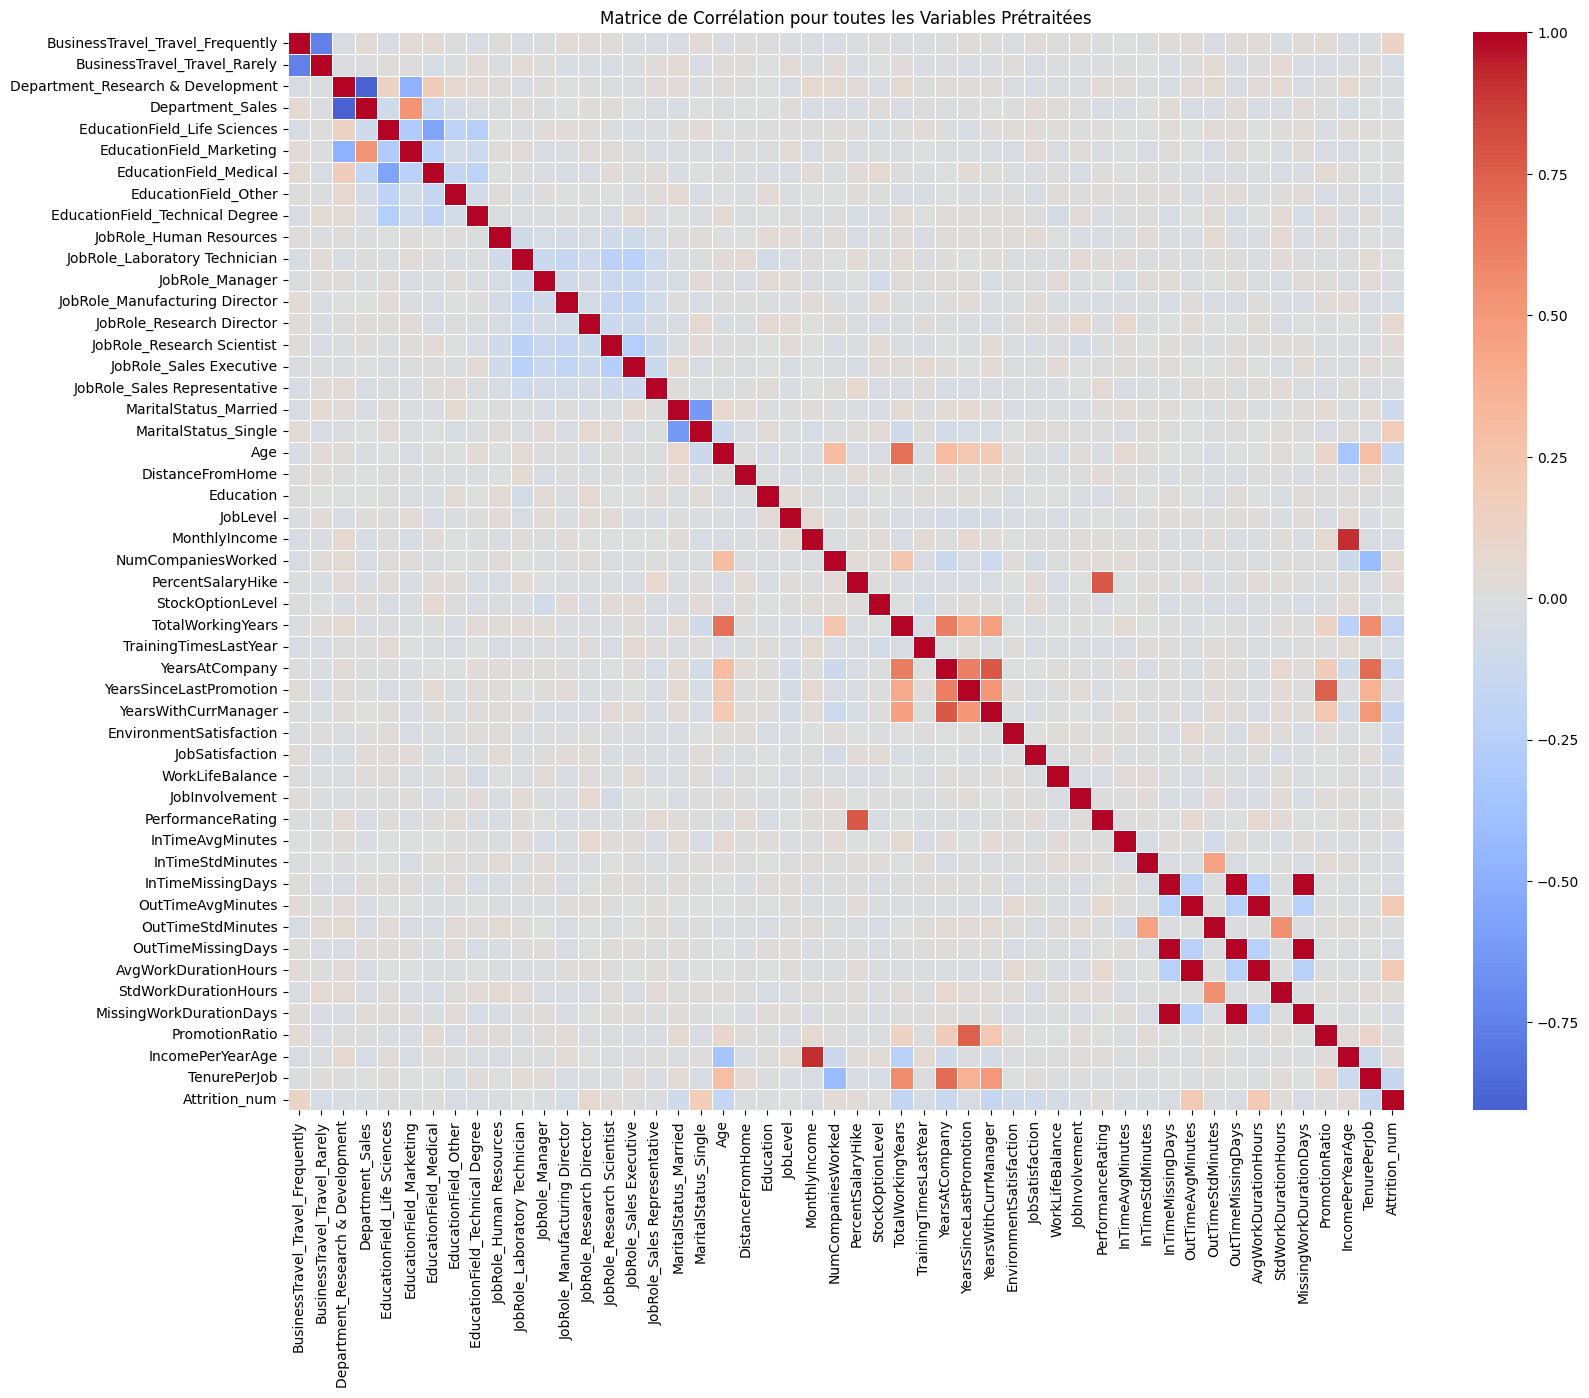

Plus fortes corrélations avec l'Attrition après prétraitement :
AvgWorkDurationHours                0.210254
OutTimeAvgMinutes                   0.209944
MaritalStatus_Single                0.182529
TotalWorkingYears                   0.172542
Age                                 0.161626
YearsWithCurrManager                0.161023
TenurePerJob                        0.151695
YearsAtCompany                      0.138415
BusinessTravel_Travel_Frequently    0.120581
EnvironmentSatisfaction             0.103878
Name: Attrition_num, dtype: float64


In [532]:
# Calculer la matrice de corrélation avec les caractéristiques encodées et les caractéristiques numériques entières
corr_data = pd.concat([encoded, df_general[numeric_features]], axis=1)
if 'Attrition_num' in df_general.columns:
    corr_data['Attrition_num'] = df_general['Attrition_num']
else:
    corr_data['Attrition_num'] = df_general['Attrition'].map({'Yes': 1, 'No': 0})

# Supprimer les colonnes constantes avant de calculer la corrélation
corr_data = corr_data.loc[:, corr_data.nunique(dropna=True) > 1]

corr = corr_data.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matrice de Corrélation pour toutes les Variables Prétraitées')
plt.show()

# Afficher les corrélations les plus fortes avec Attrition
attrition_corr = corr['Attrition_num'].drop('Attrition_num')
print('Plus fortes corrélations avec l\'Attrition après prétraitement :')
print(attrition_corr.abs().sort_values(ascending=False).head(10))

## Boîtes à moustaches des variables numériques vs Attrition

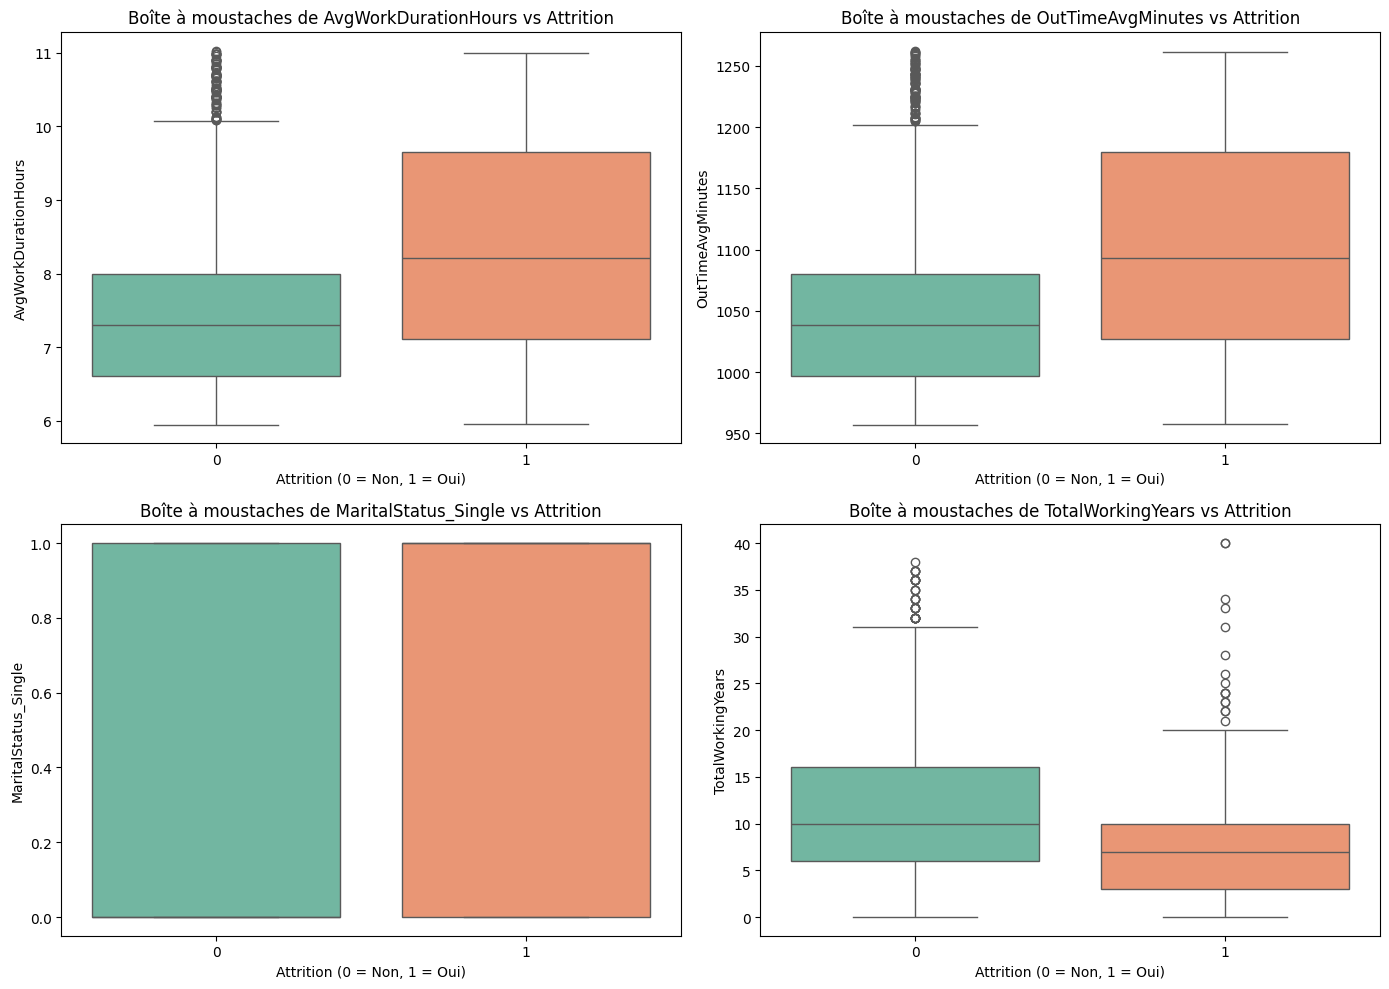

In [533]:
# Boxplots pour les 4 variables numériques les plus corrélées à l'Attrition
top_num_features = attrition_corr.abs().sort_values(ascending=False).head(4).index.tolist()

plt.figure(figsize=(14, 10))
for i, col in enumerate(top_num_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Attrition_num', y=col, hue='Attrition_num', data=corr_data, palette='Set2', legend=False)
    plt.title(f'Boîte à moustaches de {col} vs Attrition')
    plt.xlabel('Attrition (0 = Non, 1 = Oui)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

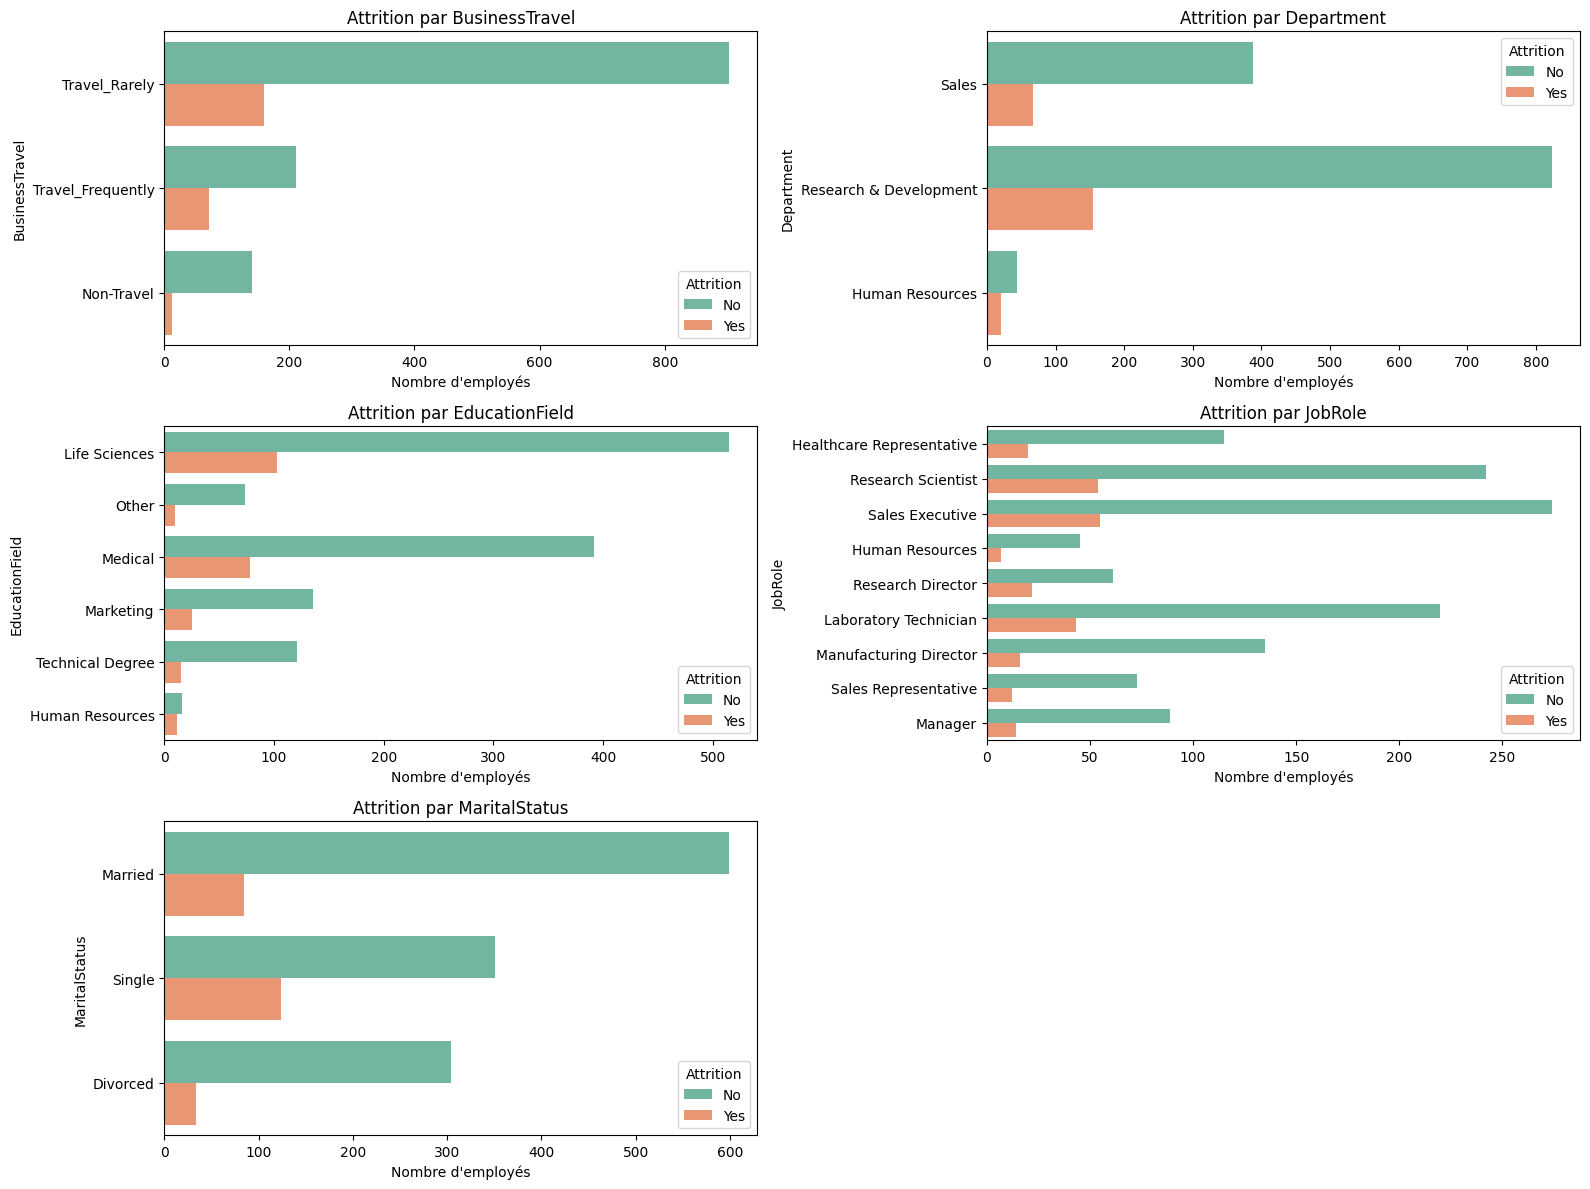

In [534]:
# Taux d'attrition sur les variables catégorielles (Barplots croisés)
plt.figure(figsize=(16, 12))
# features_to_encode contient ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
for i, col in enumerate(features_to_encode, 1):
    plt.subplot(3, 2, i)
    sns.countplot(y=col, hue='Attrition', data=df_general, palette='Set2')
    plt.title(f'Attrition par {col}')
    plt.xlabel("Nombre d'employés")
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Courbes de Régression Logistique

Meilleures caractéristiques utilisées pour la régression logistique: ['AvgWorkDurationHours', 'OutTimeAvgMinutes']


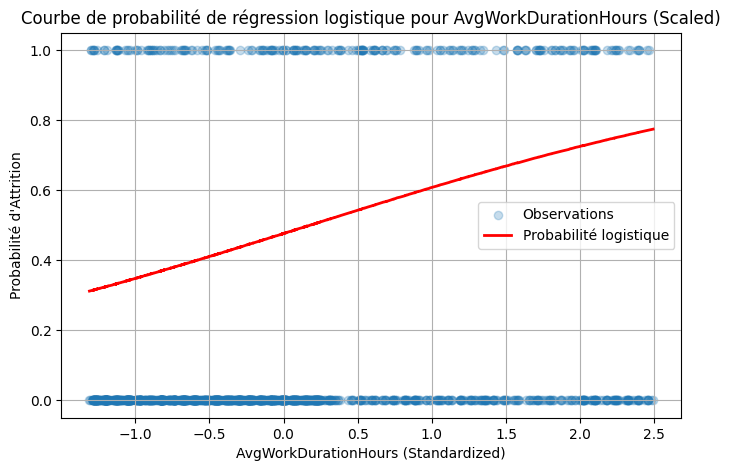

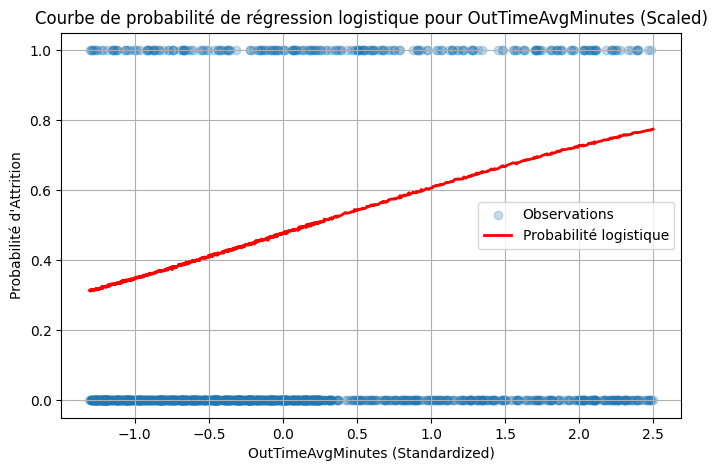

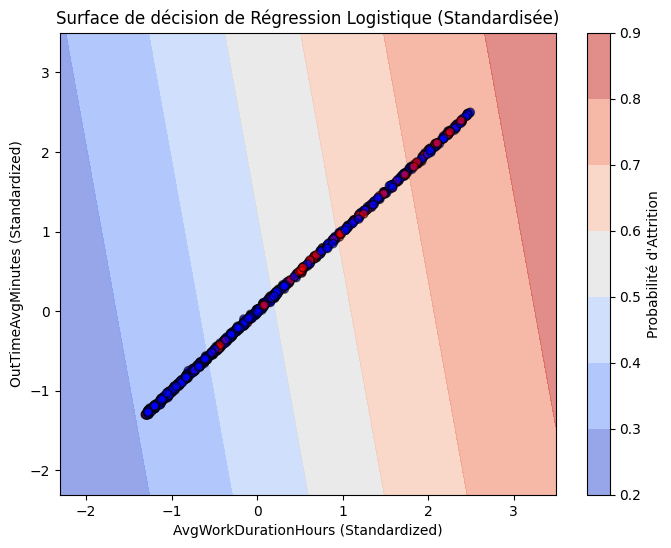

In [535]:
# Entraîner un modèle de régression logistique sur les deux caractéristiques les plus corrélées
top_features = attrition_corr.abs().sort_values(ascending=False).head(2).index.tolist()
print('Meilleures caractéristiques utilisées pour la régression logistique:', top_features)

X_log = corr_data[top_features]
y_log = corr_data['Attrition_num']

scaler_log = StandardScaler()
X_log_scaled = pd.DataFrame(scaler_log.fit_transform(X_log), columns=X_log.columns, index=X_log.index)

clf_log = LogisticRegression(max_iter=500, class_weight='balanced')
clf_log.fit(X_log_scaled, y_log)

# Tracer la courbe de probabilité pour chaque caractéristique principale séparément
for feature in top_features:
    plt.figure(figsize=(8, 5))
    idx = X_log_scaled[feature].sort_values().index
    values = X_log_scaled.loc[idx, feature].values
    probs = clf_log.predict_proba(X_log_scaled.loc[idx])[:, 1]
    plt.scatter(X_log_scaled[feature], y_log, alpha=0.25, label='Observations')
    plt.plot(values, probs, color='red', linewidth=2, label='Probabilité logistique')
    plt.title(f'Courbe de probabilité de régression logistique pour {feature} (Scaled)')
    plt.xlabel(f'{feature} (Standardized)')
    plt.ylabel('Probabilité d\'Attrition')
    plt.legend()
    plt.grid(True)
    plt.show()

# Si les deux caractéristiques sont numériques, afficher la limite de décision en 2D
if len(top_features) == 2:
    feature_x, feature_y = top_features
    x_min, x_max = X_log_scaled[feature_x].min() - 1, X_log_scaled[feature_x].max() + 1
    y_min, y_max = X_log_scaled[feature_y].min() - 1, X_log_scaled[feature_y].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_df = pd.DataFrame(grid, columns=[feature_x, feature_y])
    probs_grid = clf_log.predict_proba(grid_df)[:, 1].reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    contour = plt.contourf(xx, yy, probs_grid, cmap='coolwarm', alpha=0.6)
    plt.scatter(X_log_scaled[feature_x], X_log_scaled[feature_y], c=y_log, cmap='bwr', edgecolor='k', alpha=0.6)
    plt.colorbar(contour, label='Probabilité d\'Attrition')
    plt.title('Surface de décision de Régression Logistique (Standardisée)')
    plt.xlabel(f'{feature_x} (Standardized)')
    plt.ylabel(f'{feature_y} (Standardized)')
    plt.show()

# Préparation du Dataset

In [536]:
train_set = encoded.join(df_general[numeric_features])

# Division du Dataset

In [537]:
train_X, test_X,train_Y, test_Y = train_test_split(train_set, multi_y, test_size=0.2, random_state=1337, stratify=multi_y)

## Création d'un set de validation

In [538]:
multi_train_X, multi_val_X, multi_train_Y, multi_val_Y = train_test_split(train_X, train_Y, test_size=0.3, random_state=1337, stratify=train_Y)

scaler = StandardScaler()
multi_train_X_scaled = pd.DataFrame(scaler.fit_transform(multi_train_X), columns=multi_train_X.columns, index=multi_train_X.index)
multi_val_X_scaled = pd.DataFrame(scaler.transform(multi_val_X), columns=multi_val_X.columns, index=multi_val_X.index)
test_X_scaled = pd.DataFrame(scaler.transform(test_X), columns=test_X.columns, index=test_X.index)

## Modélisation et évaluation comparative

In [539]:
# Calculer scale_pos_weight pour XGBoost pour gérer le déséquilibre des classes
scale_pos_weight = float(np.sum(multi_train_Y == 0)) / np.sum(multi_train_Y == 1)

# Comparer plusieurs classifieurs pour sélectionner le meilleur modèle
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=1337, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=1337),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=1337, scale_pos_weight=scale_pos_weight)
}


results = []
for name, model in models.items():
    # Score F1 de validation croisée sur l'ensemble d'entraînement (utiliser Pipeline pour éviter les fuites de données)
    pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', model)])
    cv_scores = cross_val_score(pipeline, multi_train_X, multi_train_Y, cv=5, scoring='f1_weighted')
    
    # Entraîner sur l'ensemble d'entraînement en utilisant les caractéristiques standardisées
    model.fit(multi_train_X_scaled, multi_train_Y)
    
    # Prédire sur l'ensemble de validation en utilisant les caractéristiques standardisées
    proba = model.predict_proba(multi_val_X_scaled)[:, 1]
    threshold = 0.42  # à ajuster
    preds = (proba >= threshold).astype(int)
    
    results.append({
        'Model': name,
        'CV F1 Mean': cv_scores.mean(),
        'CV F1 Std': cv_scores.std(),
        'Val Accuracy': accuracy_score(multi_val_Y, preds),
        'Val Precision': precision_score(multi_val_Y, preds, average='weighted', zero_division=0),
        'Val Recall': recall_score(multi_val_Y, preds, average='weighted', zero_division=0),
        'Val F1': f1_score(multi_val_Y, preds, average='weighted', zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values(by='CV F1 Mean', ascending=False)
print(results_df)

best_model_name = results_df.iloc[0]['Model']
print(f"\nMeilleur modèle par F1 score en CV : {best_model_name}")

# Conserver le meilleur modèle pour une évaluation ultérieure
best_model = models[best_model_name]

                 Model  CV F1 Mean  CV F1 Std  Val Accuracy  Val Precision  \
3              XGBoost    0.833532   0.015174      0.813889       0.788480   
2    Gradient Boosting    0.823593   0.020937      0.830556       0.799457   
1        Random Forest    0.818285   0.020694      0.825000       0.776535   
0  Logistic Regression    0.777270   0.009394      0.694444       0.814401   

   Val Recall    Val F1  
3    0.813889  0.798499  
2    0.830556  0.808479  
1    0.825000  0.789070  
0    0.694444  0.731914  

Meilleur modèle par F1 score en CV : XGBoost


Évaluation sur le Set de Validation :
Exactitude (Accuracy) : 0.8139
Précision : 0.8734
Rappel (Recall) : 0.8139
F1-Score: 0.8319


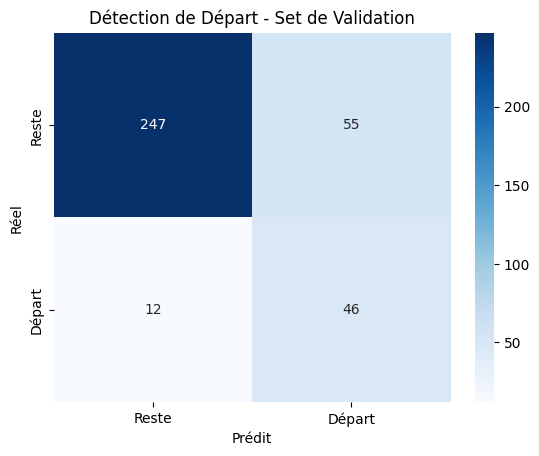

Rapport de Classification pour le Set de Validation :
              precision    recall  f1-score   support

       Reste       0.95      0.82      0.88       302
      Départ       0.46      0.79      0.58        58

    accuracy                           0.81       360
   macro avg       0.70      0.81      0.73       360
weighted avg       0.87      0.81      0.83       360



In [540]:
# Prédire et évaluer le modèle sur l'ensemble de validation
multi_predictions = rf_model_multi.predict(multi_val_X_scaled)
accuracy = accuracy_score(multi_val_Y, multi_predictions)
precision = precision_score(multi_val_Y, multi_predictions, average='weighted', zero_division=0)
recall = recall_score(multi_val_Y, multi_predictions, average='weighted', zero_division=0)
f1 = f1_score(multi_val_Y, multi_predictions, average='weighted', zero_division=0)
print(f"Évaluation sur le Set de Validation :")
print(f"Exactitude (Accuracy) : {accuracy:.4f}")
print(f"Précision : {precision:.4f}")
print(f"Rappel (Recall) : {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Matrice de Confusion pour l'ensemble de validation
conf_matrix = confusion_matrix(multi_val_Y, multi_predictions)
# 0 -> Reste (Non), 1 -> Départ (Oui)
class_labels = ['Reste', 'Départ']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title(f'Détection de Départ - Set de Validation')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# Rapport de Classification pour l'ensemble de validation
print("Rapport de Classification pour le Set de Validation :")
print(classification_report(multi_val_Y, multi_predictions, target_names=class_labels, zero_division=0))


Évaluation sur le Set de Test :
Exactitude (Accuracy) : 0.7733
Précision : 0.8019
Rappel (Recall) : 0.7733
F1-Score: 0.7855


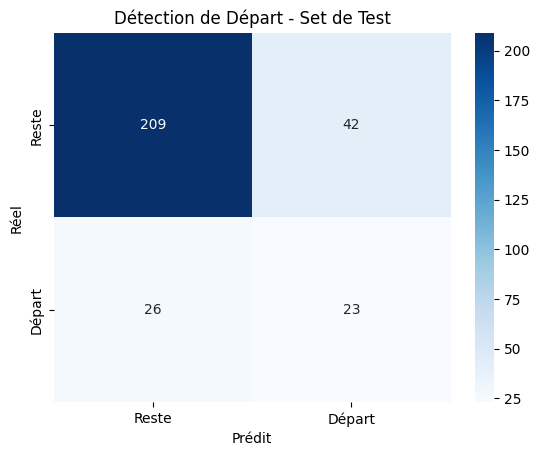

Rapport de Classification pour le Set de Test :
              precision    recall  f1-score   support

       Reste       0.89      0.83      0.86       251
      Départ       0.35      0.47      0.40        49

    accuracy                           0.77       300
   macro avg       0.62      0.65      0.63       300
weighted avg       0.80      0.77      0.79       300



In [541]:
# Évaluation finale sur l'ensemble de test
# 1. Réentraîner le normaliseur et le modèle sur l'ensemble d'entraînement complet 80% (Train + Validation)
final_scaler = StandardScaler()
full_train_X_scaled = pd.DataFrame(final_scaler.fit_transform(train_X), columns=train_X.columns, index=train_X.index)
test_X_scaled = pd.DataFrame(final_scaler.transform(test_X), columns=test_X.columns, index=test_X.index)

test_multi_predictions = rf_model_multi.predict(test_X_scaled)

test_accuracy = accuracy_score(test_Y, test_multi_predictions)
test_precision = precision_score(test_Y, test_multi_predictions, average='weighted', zero_division=0)
test_recall = recall_score(test_Y, test_multi_predictions, average='weighted', zero_division=0)
test_f1 = f1_score(test_Y, test_multi_predictions, average='weighted', zero_division=0)
print(f"\nÉvaluation sur le Set de Test :")
print(f"Exactitude (Accuracy) : {test_accuracy:.4f}")
print(f"Précision : {test_precision:.4f}")
print(f"Rappel (Recall) : {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# Matrice de Confusion pour l'ensemble de test
test_conf_matrix = confusion_matrix(test_Y, test_multi_predictions)
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title(f'Détection de Départ - Set de Test')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# Rapport de Classification pour l'ensemble de test
print("Rapport de Classification pour le Set de Test :")
print(classification_report(test_Y, test_multi_predictions, target_names=class_labels, zero_division=0))

## Courbe ROC & AUC

Score ROC AUC: 0.7433


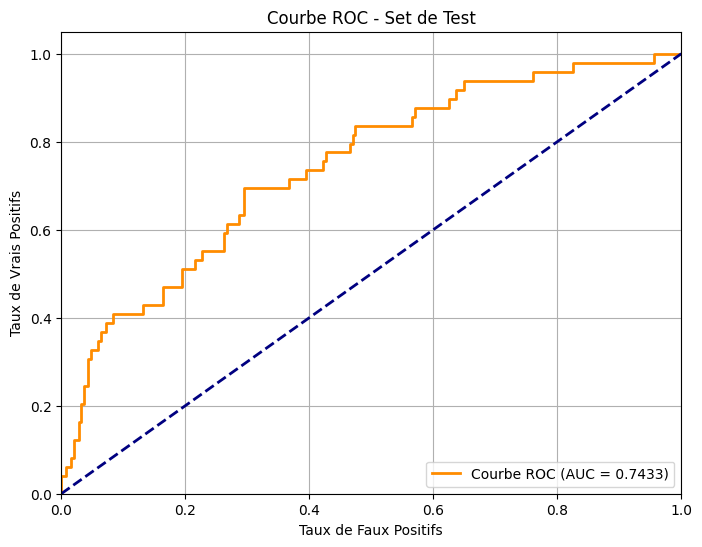

In [542]:
# Calculer les probabilités pour la classe positive
test_proba = rf_model_multi.predict_proba(test_X_scaled)[:, 1]

# Calculer l'AUC (Surface sous la courbe ROC)
roc_auc = roc_auc_score(test_Y, test_proba)
print(f"Score ROC AUC: {roc_auc:.4f}")

# Calculer les métriques de la courbe ROC
fpr, tpr, thresholds = roc_curve(test_Y, test_proba)

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC - Set de Test')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

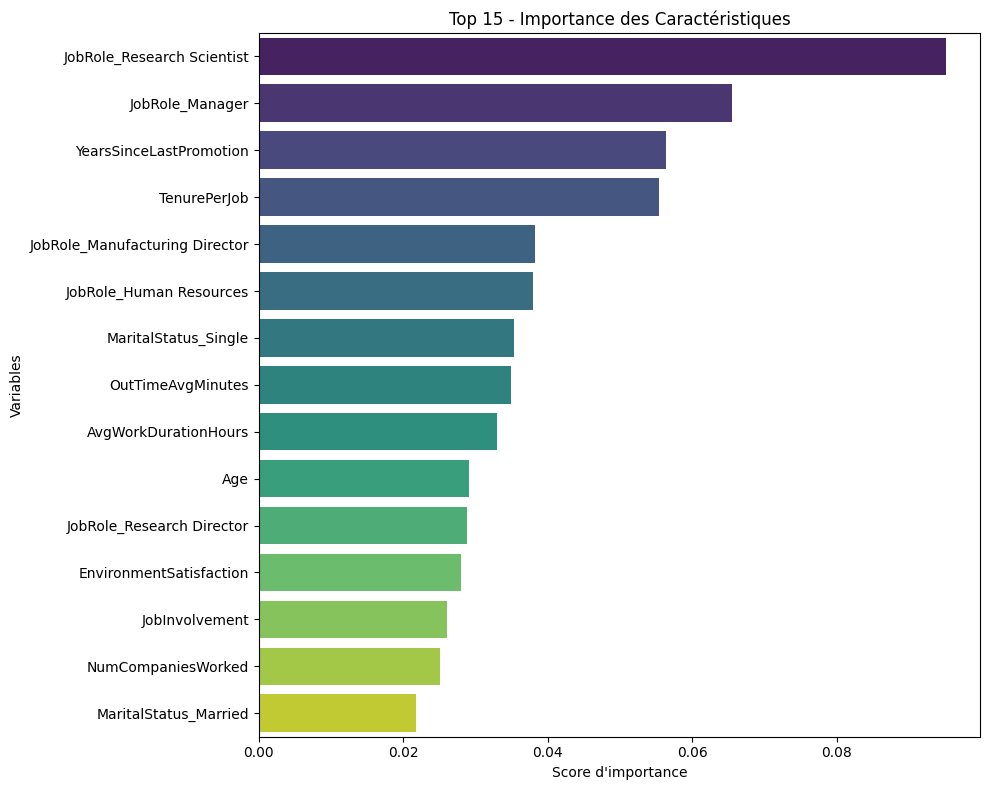

In [543]:
# Importance des Caractéristiques du Meilleur Modèle (XGBoost)
importances = best_model.feature_importances_
feature_names = multi_train_X_scaled.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feat_imp_df.head(15), palette='viridis', legend=False)
plt.title('Top 15 - Importance des Caractéristiques')
plt.xlabel("Score d'importance")
plt.ylabel('Variables')
plt.tight_layout()
plt.show()